<a href="https://colab.research.google.com/github/sarthak858-dotcom/data-science-analysis/blob/main/relationship_model_of_finacial_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👉 Upload your CSV file...


Saving Financials.csv to Financials (7).csv

✅ Loaded: 700 rows × 16 columns

⚠️ Values that couldn't be converted (now NaN):
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts              53
Sales                   0
COGS                    0
Profit                 63
Units Sold              0
dtype: int64
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    category      
 1   Country              700 non-null    category      
 2   Product              700 non-null    category      
 3   Discount Band        700 non-null    category      
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    float64       
 6   Sale Price           700 non-null    float64       
 7   Gross Sales        

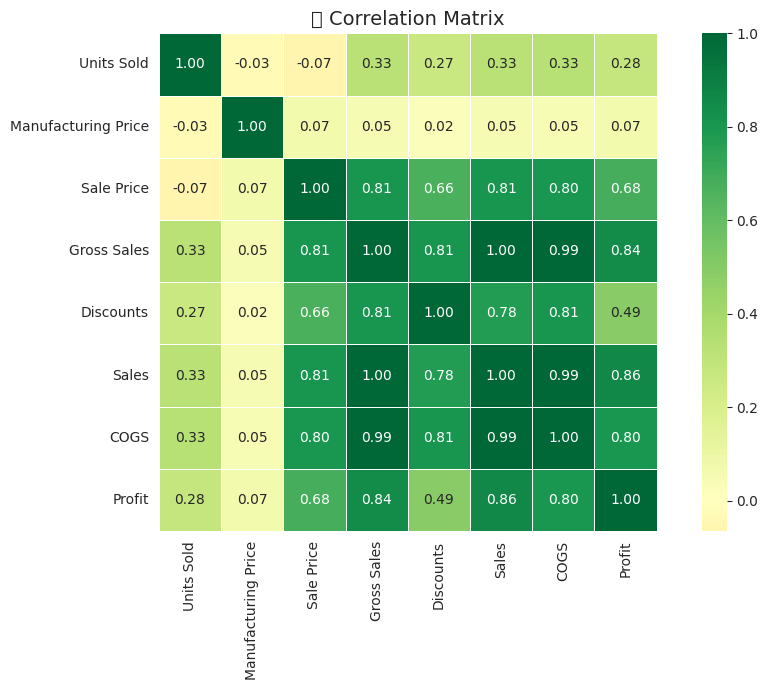

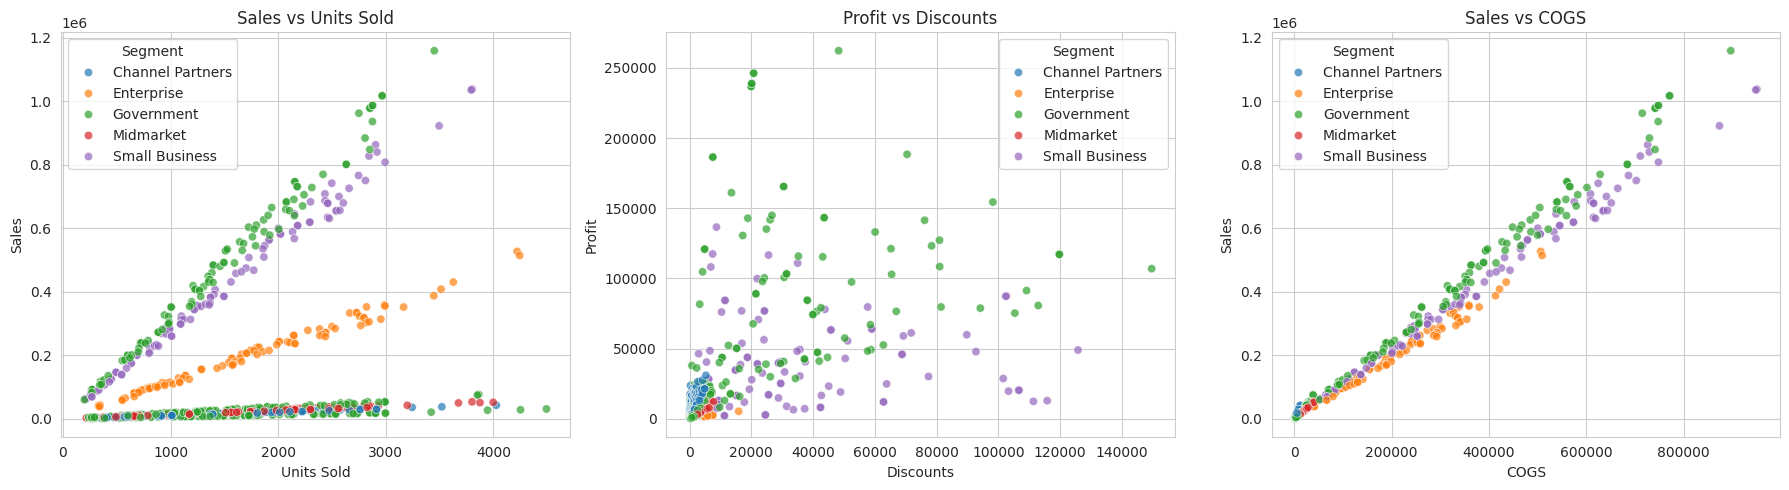

ValueError: List of boxplot statistics and `positions` values must have same the length

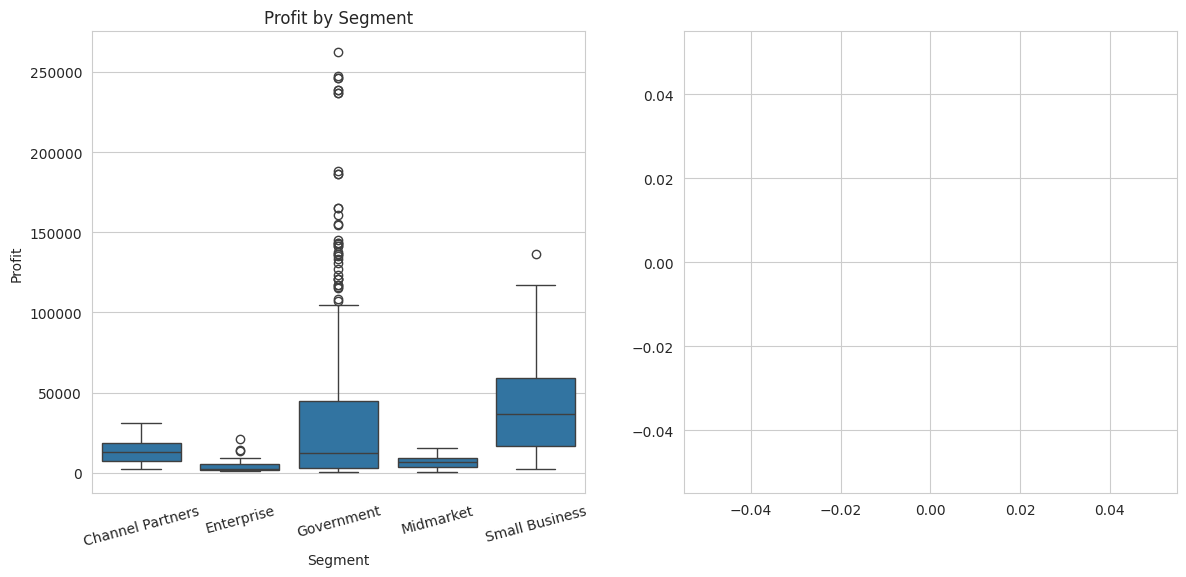

In [ ]:
# ================================================================
# 💰 FINANCIAL SAMPLE — RELATIONSHIP MODEL (ALL-IN-ONE)
# ================================================================
# Sections:
#   1. File Upload
#   2. Data Cleaning
#   3. Correlation Analysis
#   4. Visual Relationships
#   5. Predictive Models (Linear Regression + Random Forest)
#   6. Feature Importance
#   7. Predict New Data
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')

# ------------------------------------------------ 1. FILE UPLOAD
print("👉 Upload your CSV file...")
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
print(f"\n✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns\n")

# ------------------------------------------------ 2. CLEANING
df.columns = df.columns.str.strip()

money_cols = ['Manufacturing Price', 'Sale Price', 'Gross Sales',
              'Discounts', 'Sales', 'COGS', 'Profit', 'Units Sold'] # Added 'Units Sold'

for col in money_cols:
    if col in df.columns:
        # Force to string, strip whitespace, keep only digits, dots, and minus signs
        df[col] = (df[col].astype(str)
                         .str.strip()
                         .str.replace(r'[\$,]', '', regex=True)
                         .replace(['', '-', '.', '-.'], np.nan))
        # Convert safely — bad values become NaN instead of crashing
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("⚠️ Values that couldn't be converted (now NaN):")
print(df[money_cols].isnull().sum())

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

for col in ['Segment', 'Country', 'Product', 'Discount Band']:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Data Info:")
print(df.info(), "\n")
print("Missing values:\n", df.isnull().sum())

# ------------------------------------------------ 3. CORRELATION
num_df = df.select_dtypes(include=[np.number]).drop(
    columns=['Month Number', 'Year'], errors='ignore')

plt.figure(figsize=(10, 7))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('🔗 Correlation Matrix', fontsize=14)
plt.tight_layout(); plt.show()

# ------------------------------------------------ 4. VISUALS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x, y) in zip(axes, [('Units Sold', 'Sales'),
                             ('Discounts', 'Profit'),
                             ('COGS', 'Sales')]):
    sns.scatterplot(data=df, x=x, y=y, hue='Segment', ax=ax, alpha=0.7)
    ax.set_title(f'{y} vs {x}')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Changed figsize to (14, 6)
sns.boxplot(data=df, x='Segment', y='Profit', ax=axes[0])
axes[0].set_title('Profit by Segment')
axes[0].tick_params(axis='x', rotation=15)

# ✅ Build the order dynamically — only categories that actually exist
band_order = [b for b in ['None', 'Low', 'Medium', 'High']
              if b in df['Discount Band'].unique()]
sns.boxplot(data=df, x='Discount Band', y='Profit', ax=axes[1],
            order=band_order)
axes[1].set_title('Profit by Discount Band')

plt.tight_layout(); plt.show()

# ------------------------------------------------ 5. MODELS
target = 'Profit'
X = df.drop(columns=[target, 'Date'], errors='ignore')
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = {'R2': r2_score(y_test, pred),
                     'MAE': mean_absolute_error(y_test, pred),
                     'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
                     'pipeline': pipe}
    print(f"🤖 {name:<20} | R²: {results[name]['R2']:.4f} "
          f"| MAE: ${results[name]['MAE']:,.0f} "
          f"| RMSE: ${results[name]['RMSE']:,.0f}")

best_name = max(results, key=lambda k: results[k]['R2'])
best_model = results[best_name]['pipeline']
print(f"\n🏆 Best model: {best_name} "
      f"(explains {results[best_name]['R2']*100:.1f}% of Profit variance)")

# ------------------------------------------------ 6. IMPORTANCE
feat_names = best_model.named_steps['prep'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

imp_df = (pd.DataFrame({'Feature': feat_names, 'Importance': importances})
          .sort_values('Importance', ascending=False).head(12))

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('🔑 Top 12 Drivers of Profit', fontsize=14)
plt.tight_layout(); plt.show()
print(imp_df.to_string(index=False))

# ------------------------------------------------ 7. PREDICT NEW
sample = pd.DataFrame([{
    'Segment': 'Government', 'Country': 'United States of America',
    'Product': 'Paseo', 'Discount Band': 'Low',
    'Units Sold': 2000, 'Manufacturing Price': 10, 'Sale Price': 20,
    'Gross Sales': 40000, 'Discounts': 400, 'Sales': 39600, 'COGS': 20000,
    'Month Number': 9, 'Month Name': 'September', 'Year': 2014
}])
print(f"\n🔮 Predicted Profit for sample: "
      f"${best_model.predict(sample)[0]:,.2f}")

# ================================================================
# 📊 QUICK DATA ANALYSIS
# ================================================================
print("="*60)
print("📅 Period:", df['Date'].min().date(), "→", df['Date'].max().date())
print("="*60)

print("\n💰 TOTALS")
print(f"  Total Sales    : ${df['Sales'].sum():,.0f}")
print(f"  Total Profit   : ${df['Profit'].sum():,.0f}")
print(f"  Total Discounts: ${df['Discounts'].sum():,.0f}")
print(f"  Overall Margin : {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")

print("\n🏆 TOP/BOTTOM SEGMENTS BY PROFIT")
seg = df.groupby('Segment', observed=True).agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Margin=('Profit', lambda x: x.sum()/df.loc[x.index,'Sales'].sum()*100))
print(seg.sort_values('Profit', ascending=False).round(0))

print("\n🌍 PROFIT BY COUNTRY")
print(df.groupby('Country', observed=True)['Profit']
        .sum().sort_values(ascending=False).round(0))

print("\n📦 BEST PRODUCTS BY PROFIT")
print(df.groupby('Product', observed=True)['Profit']
        .sum().sort_values(ascending=False).round(0))

print("\n🏷️ EFFECT OF DISCOUNT BAND")
band = df.groupby('Discount Band', observed=True).agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Margin=('Profit', lambda x: x.sum()/df.loc[x.index,'Sales'].sum()*100))
print(band.round(1))

print("\n📆 BEST MONTHS")
df['Year-Month'] = df['Date'].dt.to_period('M')
print(df.groupby('Year-Month')['Profit'].sum()
        .sort_values(ascending=False).head(5).round(0))

print("\n⚠️ LOSS-MAKING ROWS:", (df['Profit'] < 0).sum())
print("📈 CORRELATION WITH PROFIT:")
print(df.select_dtypes(include='number')
        .corr()['Profit'].sort_values(ascending=False).round(3))

In [ ]:
# ================================================================
# 🌐 INTERACTIVE HTML DASHBOARD — exports as dashboard.html
# ================================================================
import plotly.graph_objects as go
import plotly.express as px
from google.colab import files

# ---------- 1. PREP DATA ----------
df['Year-Month'] = df['Date'].dt.to_period('M').astype(str)
df['Margin %'] = (df['Profit'] / df['Sales'] * 100).round(1)

monthly = df.groupby('Year-Month').agg(Sales=('Sales','sum'),
                                       Profit=('Profit','sum')).reset_index()
by_segment = df.groupby('Segment', observed=True).agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Units=('Units Sold','sum')).reset_index()
by_country = df.groupby('Country', observed=True).agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
by_product = df.groupby('Product', observed=True).agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
band_order = [b for b in ['None','Low','Medium','High'] if b in df['Discount Band'].unique()]
by_band = df.groupby('Discount Band', observed=True).apply(
    lambda g: pd.Series({'Sales': g['Sales'].sum(),
                         'Profit': g['Profit'].sum(),
                         'Margin': g['Profit'].sum()/g['Sales'].sum()*100}),
    include_groups=False).reindex(band_order).reset_index()

# ---------- 2. KPI NUMBERS ----------
total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_units  = df['Units Sold'].sum()
margin       = total_profit / total_sales * 100
avg_discount = df['Discounts'].sum() / df['Gross Sales'].sum() * 100
best_seg     = by_segment.loc[by_segment['Profit'].idxmax(), 'Segment']

# ---------- 3. CHARTS ----------
PALETTE = ['#636EFA','#EF553B','#00CC96','#AB63FA','#FFA15A','#19D3F3']

fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(x=monthly['Year-Month'], y=monthly['Sales'],
    name='Sales', fill='tozeroy', line=dict(color='#636EFA')))
fig_trend.add_trace(go.Scatter(x=monthly['Year-Month'], y=monthly['Profit'],
    name='Profit', fill='tozeroy', line=dict(color='#00CC96')))
fig_trend.update_layout(title='📈 Monthly Sales & Profit Trend', height=350,
                        hovermode='x unified', margin=dict(l=40,r=20,t=50,b=40))

fig_seg = px.bar(by_segment, x='Segment', y=['Sales','Profit'], barmode='group',
                 color_discrete_sequence=['#636EFA','#00CC96'],
                 title='💼 Sales & Profit by Segment', height=350)
fig_seg.update_layout(margin=dict(l=40,r=20,t=50,b=40))

fig_country = px.bar(by_country.sort_values('Sales', ascending=True),
                     x=['Sales','Profit'], y='Country', orientation='h',
                     barmode='group', color_discrete_sequence=['#636EFA','#00CC96'],
                     title='🌍 Sales & Profit by Country', height=350)
fig_country.update_layout(margin=dict(l=40,r=20,t=50,b=40))

fig_product = px.bar(by_product, x='Product', y='Profit',
                     color='Profit', color_continuous_scale='RdYlGn',
                     title='📦 Profit by Product', height=350)
fig_product.update_layout(margin=dict(l=40,r=20,t=50,b=40), showlegend=False)

fig_band = go.Figure()
fig_band.add_trace(go.Bar(x=by_band['Discount Band'], y=by_band['Margin'],
    marker_color=['#00CC96','#AB63FA','#FFA15A','#EF553B'], name='Margin %'))
fig_band.update_layout(title='🏷️ Profit Margin by Discount Band',
                       yaxis_title='Margin %', height=350,
                       margin=dict(l=40,r=20,t=50,b=40))

fig_scatter = px.scatter(df, x='Discounts', y='Profit', color='Segment',
    size='Units Sold', hover_data=['Product','Country','Discount Band'],
    color_discrete_sequence=PALETTE,
    title='💸 Discounts vs Profit (bubble size = Units Sold)', height=400)
fig_scatter.update_layout(margin=dict(l=40,r=20,t=50,b=40))

num_df = df.select_dtypes(include='number').drop(columns=['Month Number'], errors='ignore')
fig_corr = px.imshow(num_df.corr(), text_auto='.2f', color_continuous_scale='RdYlGn',
                     zmin=-1, zmax=1, title='🔗 Correlation Matrix', height=450)
fig_corr.update_layout(margin=dict(l=40,r=20,t=50,b=40))

fig_pie = px.pie(by_segment, values='Sales', names='Segment', hole=0.45,
                 color_discrete_sequence=PALETTE, title='🍩 Sales Share by Segment')
fig_pie.update_layout(height=350, margin=dict(l=20,r=20,t=50,b=20))

# ---------- 4. ASSEMBLE HTML ----------
divs = []
for i, f in enumerate([fig_trend, fig_seg, fig_country, fig_product,
                       fig_band, fig_scatter, fig_corr, fig_pie]):
    divs.append(f.to_html(full_html=False,
                          include_plotlyjs=True if i == 0 else False))

def kpi(label, value, color):
    return f'''<div class="kpi" style="border-top:4px solid {color}">
               <div class="kpi-val">{value}</div>
               <div class="kpi-label">{label}</div></div>'''

kpis = (kpi('Total Sales', f'${total_sales/1e6:.2f}M', '#636EFA')
      + kpi('Total Profit', f'${total_profit/1e6:.2f}M', '#00CC96')
      + kpi('Profit Margin', f'{margin:.1f}%', '#AB63FA')
      + kpi('Units Sold', f'{total_units/1e3:.0f}K', '#FFA15A')
      + kpi('Avg Discount', f'{avg_discount:.1f}%', '#EF553B')
      + kpi('Best Segment', best_seg, '#19D3F3'))

tables = (by_segment.to_html(index=False, float_format='%.0f', classes='tbl')
          + by_band.to_html(index=False, float_format='%.1f', classes='tbl'))

html = f'''<!DOCTYPE html>
<html><head><meta charset="utf-8"><title>Sales Dashboard</title>
<style>
  body {{ font-family:'Segoe UI',Arial,sans-serif; background:#0f1420; color:#e8eaf2; margin:0; }}
  header {{ background:linear-gradient(90deg,#1a2340,#0f1420); padding:28px 40px; }}
  header h1 {{ margin:0; font-size:26px; }} header p {{ color:#8b93ad; margin:4px 0 0; }}
  .kpis {{ display:flex; flex-wrap:wrap; gap:16px; padding:24px 40px; }}
  .kpi {{ background:#1a2235; border-radius:12px; padding:16px 24px; min-width:150px; flex:1;
          box-shadow:0 4px 12px rgba(0,0,0,.4); }}
  .kpi-val {{ font-size:24px; font-weight:700; }} .kpi-label {{ color:#8b93ad; font-size:13px; margin-top:4px; }}
  .grid {{ display:grid; grid-template-columns:repeat(auto-fit,minmax(480px,1fr)); gap:20px; padding:0 40px 30px; }}
  .chart {{ background:#1a2235; border-radius:12px; padding:10px; box-shadow:0 4px 12px rgba(0,0,0,.4); }}
  .tables {{ padding:0 40px 40px; }}
  table.tbl {{ width:100%; border-collapse:collapse; margin:14px 0; background:#1a2235; font-size:14px; }}
  .tbl th {{ background:#252f4a; padding:10px; text-align:left; }}
  .tbl td {{ padding:9px 10px; border-top:1px solid #2a3450; }}
  h2.sec {{ padding:10px 40px 0; color:#aab3cf; }}
</style></head><body>
<header><h1>💰 Financial Sales Dashboard</h1>
<p>{df['Date'].min().date()} → {df['Date'].max().date()} &nbsp;|&nbsp; {len(df)} records &nbsp;|&nbsp; Interactive — hover, zoom & click legends</p></header>
<div class="kpis">{kpis}</div>
<div class="grid">{''.join(f'<div class="chart">{d}</div>' for d in divs)}</div>
<h2 class="sec">📋 Summary Tables</h2><div class="tables">{tables}</div>
</body></html>'''

with open('dashboard.html', 'w') as f:
    f.write(html)

print("✅ dashboard.html created!")
files.download('dashboard.html')   # ⬇️ auto-downloads to your computer

✅ dashboard.html created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>